# Config

In [6]:
import pandas as pd
import numpy as np
import graphviz as gr
import networkx as nx

# 3.1. 인과관계에 대해 생각해보기

In [2]:
data = pd.read_csv("../../data/cross_sell_email.csv")
data

,gender,cross_sell_email,age,conversion
0,0,short,15,0
1,1,short,27,0
2,1,long,17,0
3,1,long,34,0
4,1,no_email,14,0
...,...,...,...,...
318,0,long,18,0
319,1,no_email,16,0
320,0,no_email,15,0
321,1,no_email,16,0


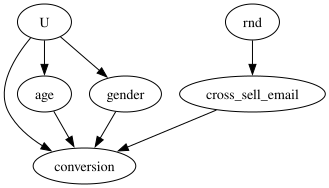

In [3]:
g_cross_sell = gr.Digraph()

g_cross_sell.edge("U", "conversion")
g_cross_sell.edge("U", "age")
g_cross_sell.edge("U", "gender")

g_cross_sell.edge("rnd", "cross_sell_email")
g_cross_sell.edge("cross_sell_email", "conversion")
g_cross_sell.edge("age", "conversion")
g_cross_sell.edge("gender", "conversion")

g_cross_sell

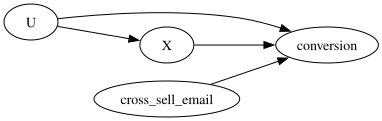

In [5]:
# rankdir: LR인 경우, 그래프가 왼쪽에서 오른쪽으로 화살표가 향햐도록 설정
g_cross_sell = gr.Digraph(graph_attr={"rankdir": "LR"})

g_cross_sell.edge("U", "conversion")
g_cross_sell.edge("U", "X")

g_cross_sell.edge("cross_sell_email", "conversion")
g_cross_sell.edge("X", "conversion")

g_cross_sell

# 3.2. 그래프 모델 집중 훈련

In [7]:
model = nx.DiGraph([
    ("C", "A"),
    ("C", "B"),
    ("D", "A"),
    ("B", "E"),
    ("F", "E"),
    ("A", "G"),
])

In [10]:
print("Are D and C dependent?")
print(not(nx.is_d_separator(model, {"D"}, {"C"}, set())))

print("Are D and C dependent given A?")
print(not(nx.is_d_separator(model, {"D"}, {"C"}, {"A"})))

print("Are D and C dependent given G?")
print(not(nx.is_d_separator(model, {"D"}, {"C"}, {"G"})))

Are D and C dependent?
False
Are D and C dependent given A?
True
Are D and C dependent given G?
True


In [13]:
print("Are G and D dependent?")
print(not(nx.is_d_separator(model, {"G"}, {"D"}, set())))

print("Are G and D dependent given A?")
print(not(nx.is_d_separator(model, {"G"}, {"D"}, {"A"})))

Are G and D dependent?
True
Are G and D dependent given A?
False


In [14]:
print("Are A and B dependent?")
print(not(nx.is_d_separator(model, {"A"}, {"B"}, set())))

print("Are A and B dependent given C?")
print(not(nx.is_d_separator(model, {"A"}, {"B"}, {"C"})))

Are A and B dependent?
True
Are A and B dependent given C?
False


In [15]:
print("Are G and F dependent?")
print(not(nx.is_d_separator(model, {"G"}, {"F"}, set())))

print("Are G and F dependent given E?")
print(not(nx.is_d_separator(model, {"G"}, {"F"}, {"E"})))

Are G and F dependent?
False
Are G and F dependent given E?
True


# 3.3 식별 재해석

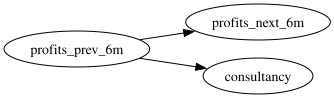

In [ ]:
consultancy_sev = gr.Digraph(graph_attr={"rankdir": "LR"})
consultancy_sev.edge("profits_prev_6m", "profits_next_6m")
consultancy_sev.edge("profits_prev_6m", "consultancy")

consultancy_sev

In [20]:
consultancy_model_severed = nx.DiGraph([
    ("profits_prev_6m", "profits_next_6m"),
    ("profits_prev_6m", "consultancy"),
#     ("consultancy", "profits_next_6m"), # causal relationship removed
])

not(nx.is_d_separator(consultancy_model_severed,
                   {"consultancy"}, {"profits_next_6m"}, set()))

True

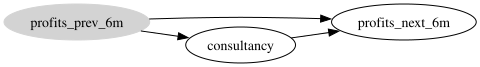

In [21]:
g_consultancy = gr.Digraph(graph_attr={"rankdir":"LR"})
g_consultancy.edge("profits_prev_6m", "profits_next_6m")
g_consultancy.edge("profits_prev_6m", "consultancy")
g_consultancy.edge("consultancy", "profits_next_6m")
g_consultancy.node("profits_prev_6m", color="lightgrey", style="filled")

g_consultancy

# 3.6. 구체적인 식별 예제

In [22]:
df = pd.DataFrame(dict(
    profits_prev_6m=[1.0, 1.0, 1.0, 5.0, 5.0, 5.0],
    consultancy=[0, 0, 1, 0, 1, 1],
    profits_next_6m=[1, 1.1, 1.2, 5.5, 5.7, 5.7],
))

df

,profits_prev_6m,consultancy,profits_next_6m
0,1.0,0,1.0
1,1.0,0,1.1
2,1.0,1,1.2
3,5.0,0,5.5
4,5.0,1,5.7
5,5.0,1,5.7


In [23]:
(df.query("consultancy==1")["profits_next_6m"].mean() 
 - df.query("consultancy==0")["profits_next_6m"].mean())

np.float64(1.666666666666667)

In [24]:
avg_df = (df
          .groupby(["consultancy", "profits_prev_6m"])
          ["profits_next_6m"]
          .mean())

avg_df.loc[1] - avg_df.loc[0] 

profits_prev_6m
1.0    0.15
5.0    0.20
Name: profits_next_6m, dtype: float64

# 3.8. 선택편향

In [26]:
nps_model = nx.DiGraph([
   ("RND", "New Feature"),
#     ("New Feature", "Customer Satisfaction"),
    ("Customer Satisfaction", "NPS"),
    ("Customer Satisfaction", "Response"),
    ("New Feature", "Response"),
])


not(nx.is_d_separator(nps_model, {"NPS"}, {"New Feature"}, {"Response"}))

True